# 02 — Model 3: Bin Behavior Clustering (K-Means)
Segments the 154 bins into behavioral groups from their **aggregated** history (not daily rows).
Two uses (see `ML_PIPELINE_PLAN.md` §6.3):
1. `bin_cluster_id` is merged back in as a categorical feature for Models 1 & 2 (Notebooks 03/04).
2. Cluster membership directly supports the non-ML **Bin Demand Score** used for placement/capacity decisions.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from feature_engineering import load_raw, build_features, build_bin_aggregates, chronological_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


## 1. Build per-bin aggregate features
**Fit on training-period rows only** (`ML_PIPELINE_PLAN.md` §6.4 / §9 checklist item 4). All 154 bins
already appear in the training window, so this doesn't lose any bin — but it keeps the clustering
model, like Models 1 & 2, from ever seeing validation/test-period fill and overflow outcomes. Fitting
on the full 2-year span (train+val+test) would leak future per-bin behavior into `bin_cluster_id`,
which Notebooks 03/04 then use as a feature and evaluate on that same test period.

In [2]:
df = build_features(load_raw())
train, _, _ = chronological_split(df)
agg = build_bin_aggregates(train)
agg = agg.fillna(agg.median(numeric_only=True))
agg.head()

,bin_id,zone_id,zone_name,zone_type,bin_capacity_liters,avg_fill_pct,std_fill_pct,avg_waste_kg_per_day,overflow_rate,avg_days_between_collections,festival_sensitivity,weekend_sensitivity,rain_sensitivity
0,BIN0001,Z01,Hampankatta,market,660,36.023870,18.447208,30.153789,0.007286,0.0,2.134014,1.122197,0.804462
1,BIN0002,Z01,Hampankatta,market,1100,52.753725,24.186067,76.610874,0.043716,0.0,2.045587,1.117314,0.791065
2,BIN0003,Z01,Hampankatta,market,660,66.781278,27.630365,60.117413,0.105647,0.0,1.888086,1.165558,0.807747
3,BIN0004,Z01,Hampankatta,market,660,50.109074,24.062952,42.872459,0.041894,0.0,2.205802,1.108814,0.791483
4,BIN0005,Z01,Hampankatta,market,1100,68.869372,28.409871,163.332204,0.102004,0.0,1.818950,1.143800,0.817692


In [3]:
CLUSTER_FEATURES = [
    "avg_fill_pct", "std_fill_pct", "avg_waste_kg_per_day", "overflow_rate",
    "avg_days_between_collections", "festival_sensitivity", "weekend_sensitivity", "rain_sensitivity",
]
X = agg[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(154, 8)

## 2. Choose k — elbow method + silhouette score

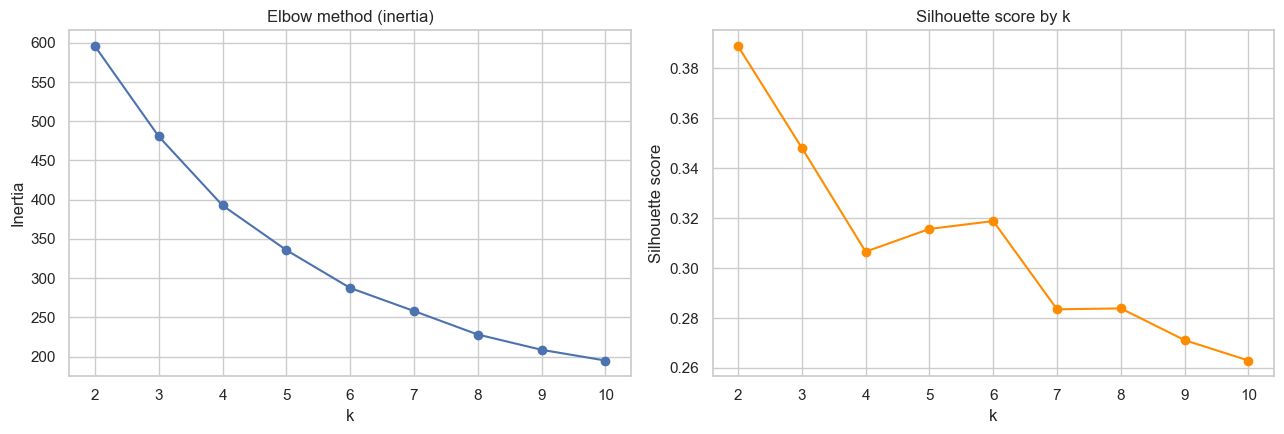

Silhouette-optimal k: 2  (scores: {2: np.float64(0.389), 3: np.float64(0.348), 4: np.float64(0.307), 5: np.float64(0.316), 6: np.float64(0.319), 7: np.float64(0.283), 8: np.float64(0.284), 9: np.float64(0.271), 10: np.float64(0.263)} )


In [4]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(list(ks), sils, marker="o", color="darkorange")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(sils))]
print("Silhouette-optimal k:", best_k, " (scores:", dict(zip(ks, np.round(sils, 3))), ")")

In [5]:
# Favor an interpretable k in a reasonable range (4-6) for a hackathon demo,
# but never override a clearly better silhouette result outside that range.
K = best_k if best_k in range(3, 8) else 5
print("Using k =", K)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
agg["bin_cluster_id"] = kmeans.fit_predict(X_scaled)
print("Final silhouette score:", round(silhouette_score(X_scaled, agg["bin_cluster_id"]), 3))

Using k = 5
Final silhouette score: 0.316


## 3. Visualize clusters in 2D (PCA)

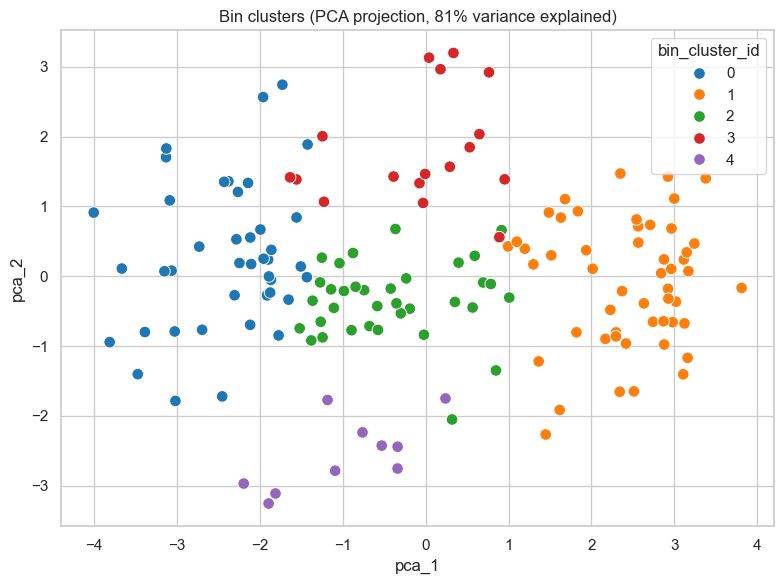

In [6]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
agg["pca_1"], agg["pca_2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=agg, x="pca_1", y="pca_2", hue="bin_cluster_id", palette="tab10", s=70)
plt.title(f"Bin clusters (PCA projection, {pca.explained_variance_ratio_.sum()*100:.0f}% variance explained)")
plt.tight_layout(); plt.show()

## 4. Cluster profiles — what does each cluster represent?

In [7]:
profile = agg.groupby("bin_cluster_id")[CLUSTER_FEATURES + ["bin_capacity_liters"]].mean().round(2)
profile["n_bins"] = agg["bin_cluster_id"].value_counts().sort_index()
profile

,avg_fill_pct,std_fill_pct,avg_waste_kg_per_day,overflow_rate,avg_days_between_collections,festival_sensitivity,weekend_sensitivity,rain_sensitivity,bin_capacity_liters,n_bins
bin_cluster_id,,,,,,,,,,
0,45.46,21.97,40.61,0.03,0.0,2.12,1.17,0.77,669.27,41
1,72.56,29.92,34.27,0.20,0.0,1.49,1.02,0.93,472.55,51
2,57.17,24.80,27.15,0.05,0.0,1.75,1.10,0.85,449.71,35
3,64.33,27.30,105.98,0.10,0.0,1.83,1.13,0.81,944.71,17
4,44.47,20.80,22.12,0.02,0.0,1.86,0.83,0.89,460.00,10


In [8]:
# Sanity check: do clusters line up with zone_type at all, or are they cutting across it
# in a genuinely new way (both are useful outcomes)?
pd.crosstab(agg["bin_cluster_id"], agg["zone_type"])

zone_type,commercial,industrial,institutional,market,mixed_use,residential_high,residential_low,tourist
bin_cluster_id,,,,,,,,
0,4,0,0,26,1,0,0,10
1,11,5,3,0,9,12,11,0
2,15,0,0,8,10,1,1,0
3,1,0,0,13,2,0,0,1
4,0,0,9,0,0,1,0,0


In [9]:
# Auto-label clusters using simple rules on the profile, purely for readability in the demo
def label_cluster(row):
    if row["overflow_rate"] > profile["overflow_rate"].median() and row["avg_fill_pct"] > profile["avg_fill_pct"].median():
        return "high_risk_chronic_overflow"
    if row["festival_sensitivity"] > 1.3 or row["weekend_sensitivity"] > 1.3:
        return "event_spiky"
    if row["avg_waste_kg_per_day"] > profile["avg_waste_kg_per_day"].median():
        return "high_volume_steady"
    return "low_volume_stable"

profile["cluster_label"] = profile.apply(label_cluster, axis=1)
profile[["n_bins", "avg_fill_pct", "overflow_rate", "festival_sensitivity", "weekend_sensitivity", "cluster_label"]]

,n_bins,avg_fill_pct,overflow_rate,festival_sensitivity,weekend_sensitivity,cluster_label
bin_cluster_id,,,,,,
0,41,45.46,0.03,2.12,1.17,event_spiky
1,51,72.56,0.20,1.49,1.02,high_risk_chronic_overflow
2,35,57.17,0.05,1.75,1.10,event_spiky
3,17,64.33,0.10,1.83,1.13,high_risk_chronic_overflow
4,10,44.47,0.02,1.86,0.83,event_spiky


## 5. Save the bin  cluster mapping
This file is imported by Notebooks 03 and 04 (`feature_engineering.merge_cluster_labels`).

In [10]:
out = agg[["bin_id", "zone_type", "zone_name", "bin_cluster_id"]].merge(
    profile[["cluster_label"]], left_on="bin_cluster_id", right_index=True
)
out.to_csv("bin_cluster_mapping.csv", index=False)
print("Saved bin_cluster_mapping.csv:", out.shape)
out.head()

Saved bin_cluster_mapping.csv: (154, 5)


,bin_id,zone_type,zone_name,bin_cluster_id,cluster_label
0,BIN0001,market,Hampankatta,0,event_spiky
1,BIN0002,market,Hampankatta,0,event_spiky
2,BIN0003,market,Hampankatta,3,high_risk_chronic_overflow
3,BIN0004,market,Hampankatta,0,event_spiky
4,BIN0005,market,Hampankatta,3,high_risk_chronic_overflow


## 6. Summary
- K-Means on 8 behavioral aggregates (fill level, volatility, overflow rate, collection cadence, festival/weekend/rain sensitivity) segments the 154 bins into interpretable groups.
- Clusters partially — but not fully — align with `zone_type`, confirming they add information beyond the static zone label (otherwise clustering would be redundant).
- `bin_cluster_mapping.csv` is consumed by the regression (03) and classification (04) notebooks as an extra categorical feature, and by the (non-ML) Bin Demand Score step in the wider architecture for placement/capacity decisions.